We load the dataset and scale all features before clustering.

### Why scaling is important:
K-Means uses distance-based calculations (Euclidean distance).  
If features are on different scales (e.g., age vs annual_spend), variables with larger values dominate the clustering process.

Scaling ensures:
- Equal importance to all features
- Better cluster formation
- Faster convergence

In [1]:
## 1. Data Preparation

# Customer Segmentation using K-Means

import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv(r'E:\Bitsom\Assignment\Machine Learning\data\q2_customers.csv')

df.head()
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

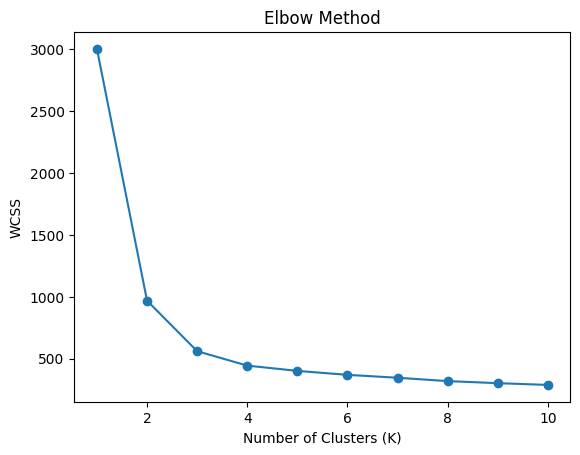

In [2]:
## 2. Choosing K — Elbow Method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

## Optimal Number of Clusters

From the elbow plot, the most prominent bend occurs at **K = 3**.

- There is a sharp decrease in WCSS from K = 1 to K = 3
- After K = 3, the reduction in WCSS becomes gradual and less significant

### Conclusion:
K = 3 is selected as the optimal number of clusters as it captures the major structure in the data while avoiding unnecessary complexity.

In [3]:
## 3. K-Means Clustering

# Fit KMeans
k_optimal = 3  # change if needed

kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster column
df['cluster'] = clusters

In [4]:
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


## Cluster Interpretation

### Cluster 0: Young, Low-Spend, High-Frequency Customers
- Average age ~25 years
- Low annual spend (~15K)
- High visit frequency (~14 visits/month)
- Small basket size
- Very recent visits (low days since last visit)

## Interpretation:
These are young, highly engaged customers who visit frequently but spend less per visit. They are likely price-sensitive and responsive to small-ticket purchases.

## Business Strategy:
- Offer bundle deals or upselling strategies  
- Introduce loyalty rewards to increase basket size  
- Promote add-on purchases at checkout  

---

### Cluster 1: High-Value, Infrequent Premium Customers
- Older customers (~57 years)
- Very high annual spend (~89K)
- Low visit frequency (~2.5 visits/month)
- Very large basket size
- High recency gap (~105 days since last visit)

## Interpretation:
These are premium customers who spend heavily but visit infrequently. Their high basket size suggests bulk or planned purchases.

## Business Strategy:
- Target with personalized offers and premium services  
- Use re-engagement campaigns (since high days since last visit)  
- Provide exclusive deals or memberships  

---

### Cluster 2: Moderate, Balanced Customers
- Middle-aged (~40 years)
- متوسط annual spend (~43K)
- Moderate visit frequency (~8 visits/month)
- Medium basket size
- متوسط recency (~35 days)

## Interpretation:
These are steady, balanced customers with consistent behavior across all metrics.

## Business Strategy:*
- Maintain engagement through regular promotions  
- Cross-sell across product categories  
- Encourage gradual increase in spend  

---

## Overall Insight:
The segmentation reveals three distinct customer groups — high-frequency low spenders, high-value infrequent buyers, and balanced mid-tier customers.

This enables targeted marketing strategies to maximize revenue and customer retention.

In [5]:
## 4. PCA (Dimensionality Reduction)

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Explained variance
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
)

loadings

Explained Variance Ratio: [0.83560354 0.05568764]


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


## PCA Interpretation

### Explained Variance:
- PC1 explains ~83.6% of the variance
- PC2 explains ~5.6% of the variance

This indicates that most of the information in the dataset is captured by the first principal component.


### Principal Component Analysis:

#### PC1 (Primary Driver — Overall Customer Value & Activity)
PC1 has strong positive loadings from:
- annual_spend
- basket_size
- num_categories_purchased
- age
- days_since_last_visit  

and a negative contribution from:
- visits_per_month

**Interpretation:**  
PC1 primarily represents overall customer value and purchasing intensity.  
Customers with high PC1 scores tend to:
- Spend more
- Purchase across more categories
- Have larger basket sizes

---

#### PC2 (Secondary Driver — Recency & Engagement Pattern)
PC2 is strongly influenced by:
- days_since_last_visit, very high loading ~0.91

and moderately by:
- visits_per_month

**Interpretation:**  
PC2 captures customer recency and engagement behavior.  
Higher PC2 values indicate customers who:
- Have not visited recently
- May be at risk of churn

---

### Conclusion:
PCA effectively reduces the dataset into two meaningful dimensions:
- PC1: Customer value and spending behavior  
- PC2: Customer recency and engagement  

This allows clear visualization of customer segments while retaining most of the original information.

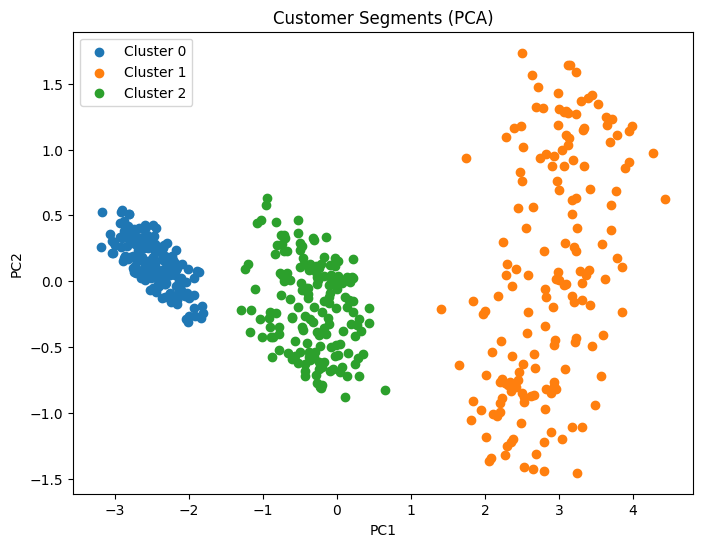

In [6]:
## 5. Cluster Visualisation

plt.figure(figsize=(8,6))

for cluster in range(k_optimal):
    plt.scatter(
        X_pca[df['cluster'] == cluster, 0],
        X_pca[df['cluster'] == cluster, 1],
        label=f'Cluster {cluster}'
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segments (PCA)")
plt.legend()
plt.show()